# Stage 4 — Model Training, Evaluation & Selection
**Input :** X_train.csv, X_test.csv, y_train.csv, y_test.csv (from Stage 3)
**Target :** Price (INR)
**Models :** Linear Regression → Random Forest → XGBoost
**Output :** model.pkl (best model ready for Stage 5 deployment)

---
## 0. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

# Load splits from Stage 3
X_train = pd.read_csv('X_train.csv')
X_test  = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test  = pd.read_csv('y_test.csv').squeeze()

# Load scaled versions (for Linear Regression)
X_train_scaled = pd.read_csv('X_train_scaled.csv')
X_test_scaled  = pd.read_csv('X_test_scaled.csv')

FEATURES = joblib.load('feature_names.pkl')

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train.shape}')
print(f'y_test  : {y_test.shape}')
print(f'Features: {len(FEATURES)}')

X_train : (205, 23)
X_test  : (52, 23)
y_train : (205,)
y_test  : (52,)
Features: 23


---
## 1. Evaluation Helper

In [2]:
results = []   # collect all model results here

def evaluate(name, model, X_tr, X_te, y_tr, y_te, store=True):
    """
    Fits model, prints RMSE / MAE / R2,
    and stores results for comparison table.
    Returns (model, predictions).
    """
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae  = mean_absolute_error(y_te, preds)
    r2   = r2_score(y_te, preds)

    # Cross-val R2 on training set (3 folds — safe for 258 rows)
    cv_r2 = cross_val_score(model, X_tr, y_tr, cv=3,
                             scoring='r2', n_jobs=-1).mean()

    print(f'  {name}')
    print(f'    RMSE  : ₹{rmse:>12,.0f}')
    print(f'    MAE   : ₹{mae:>12,.0f}')
    print(f'    R²    : {r2:.4f}')
    print(f'    CV R² : {cv_r2:.4f}  (3-fold on train)')
    print()

    if store:
        results.append({
            'Model': name,
            'RMSE (₹)': round(rmse),
            'MAE (₹)':  round(mae),
            'R²':        round(r2, 4),
            'CV R²':     round(cv_r2, 4),
        })
    return model, preds

---
## 2. Model 1 — Linear Regression (Baseline)

In [3]:
print('=== Linear Regression ===')
lr, preds_lr = evaluate(
    'Linear Regression',
    LinearRegression(),
    X_train_scaled, X_test_scaled, y_train, y_test
)

=== Linear Regression ===
  Linear Regression
    RMSE  : ₹     311,488
    MAE   : ₹     216,756
    R²    : 0.4078
    CV R² : 0.1792  (3-fold on train)



In [4]:
print('=== Ridge Regression (L2 regularised baseline) ===')
ridge, preds_ridge = evaluate(
    'Ridge Regression',
    Ridge(alpha=10),
    X_train_scaled, X_test_scaled, y_train, y_test
)

=== Ridge Regression (L2 regularised baseline) ===
  Ridge Regression
    RMSE  : ₹     314,542
    MAE   : ₹     211,007
    R²    : 0.3962
    CV R² : 0.2450  (3-fold on train)



---
## 3. Model 2 — Random Forest Regressor

In [5]:
print('=== Random Forest (default) ===')
rf_base, preds_rf_base = evaluate(
    'Random Forest (default)',
    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    X_train, X_test, y_train, y_test
)

=== Random Forest (default) ===
  Random Forest (default)
    RMSE  : ₹     194,747
    MAE   : ₹     137,073
    R²    : 0.7685
    CV R² : 0.4764  (3-fold on train)



In [6]:
# Hyperparameter tuning for Random Forest
print('=== Random Forest — GridSearchCV tuning ===')
rf_param_grid = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features':    ['sqrt', 'log2']
}
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)
print('Best RF params:', rf_grid.best_params_)

rf_tuned, preds_rf = evaluate(
    'Random Forest (tuned)',
    rf_grid.best_estimator_,
    X_train, X_test, y_train, y_test,
    store=False   # already fitted — re-evaluate only
)
# Store manually with tuned tag
preds_rf  = rf_grid.best_estimator_.predict(X_test)
results.append({
    'Model':    'Random Forest (tuned)',
    'RMSE (₹)': round(np.sqrt(mean_squared_error(y_test, preds_rf))),
    'MAE (₹)':  round(mean_absolute_error(y_test, preds_rf)),
    'R²':        round(r2_score(y_test, preds_rf), 4),
    'CV R²':     round(cross_val_score(rf_grid.best_estimator_,
                        X_train, y_train, cv=3, scoring='r2').mean(), 4),
})

=== Random Forest — GridSearchCV tuning ===
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best RF params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
  Random Forest (tuned)
    RMSE  : ₹     282,331
    MAE   : ₹     174,177
    R²    : 0.5135
    CV R² : 0.3629  (3-fold on train)



---
## 4. Model 3 — Gradient Boosting (XGBoost style)

In [7]:
print('=== Gradient Boosting (default) ===')
gb_base, preds_gb_base = evaluate(
    'Gradient Boosting (default)',
    GradientBoostingRegressor(n_estimators=300, random_state=42),
    X_train, X_test, y_train, y_test
)

=== Gradient Boosting (default) ===
  Gradient Boosting (default)
    RMSE  : ₹     185,179
    MAE   : ₹     111,867
    R²    : 0.7907
    CV R² : 0.4419  (3-fold on train)



In [8]:
# Hyperparameter tuning for Gradient Boosting
print('=== Gradient Boosting — GridSearchCV tuning ===')
gb_param_grid = {
    'n_estimators':  [200, 300, 400],
    'learning_rate': [0.05, 0.1, 0.15],
    'max_depth':     [3, 4, 5],
    'subsample':     [0.8, 1.0]
}
gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)
gb_grid.fit(X_train, y_train)
print('Best GB params:', gb_grid.best_params_)

preds_gb = gb_grid.best_estimator_.predict(X_test)
results.append({
    'Model':    'Gradient Boosting (tuned)',
    'RMSE (₹)': round(np.sqrt(mean_squared_error(y_test, preds_gb))),
    'MAE (₹)':  round(mean_absolute_error(y_test, preds_gb)),
    'R²':        round(r2_score(y_test, preds_gb), 4),
    'CV R²':     round(cross_val_score(gb_grid.best_estimator_,
                        X_train, y_train, cv=3, scoring='r2').mean(), 4),
})
print(f"  Gradient Boosting (tuned)")
print(f"    RMSE : ₹{results[-1]['RMSE (₹)']:,}")
print(f"    MAE  : ₹{results[-1]['MAE (₹)']:,}")
print(f"    R²   : {results[-1]['R²']}")

=== Gradient Boosting — GridSearchCV tuning ===
Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best GB params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 400, 'subsample': 1.0}
  Gradient Boosting (tuned)
    RMSE : ₹175,486
    MAE  : ₹110,986
    R²   : 0.8121


---
## 5. Model Comparison Table

In [10]:
df_results = pd.DataFrame(results).sort_values('R²', ascending=False)
df_results.reset_index(drop=True, inplace=True)

print('='*70)
print('                    MODEL COMPARISON')
print('='*70)
print(df_results.to_string(index=False))
print('='*70)

best_model_name = df_results.iloc[0]['Model']
print(f'\nBest model: {best_model_name}')

                    MODEL COMPARISON
                      Model  RMSE (₹)  MAE (₹)     R²  CV R²
  Gradient Boosting (tuned)    175486   110986 0.8121 0.4831
Gradient Boosting (default)    185179   111867 0.7907 0.4419
    Random Forest (default)    194747   137073 0.7685 0.4764
      Random Forest (tuned)    282331   174177 0.5135 0.3629
          Linear Regression    311488   216756 0.4078 0.1792
           Ridge Regression    314542   211007 0.3962 0.2450

Best model: Gradient Boosting (tuned)


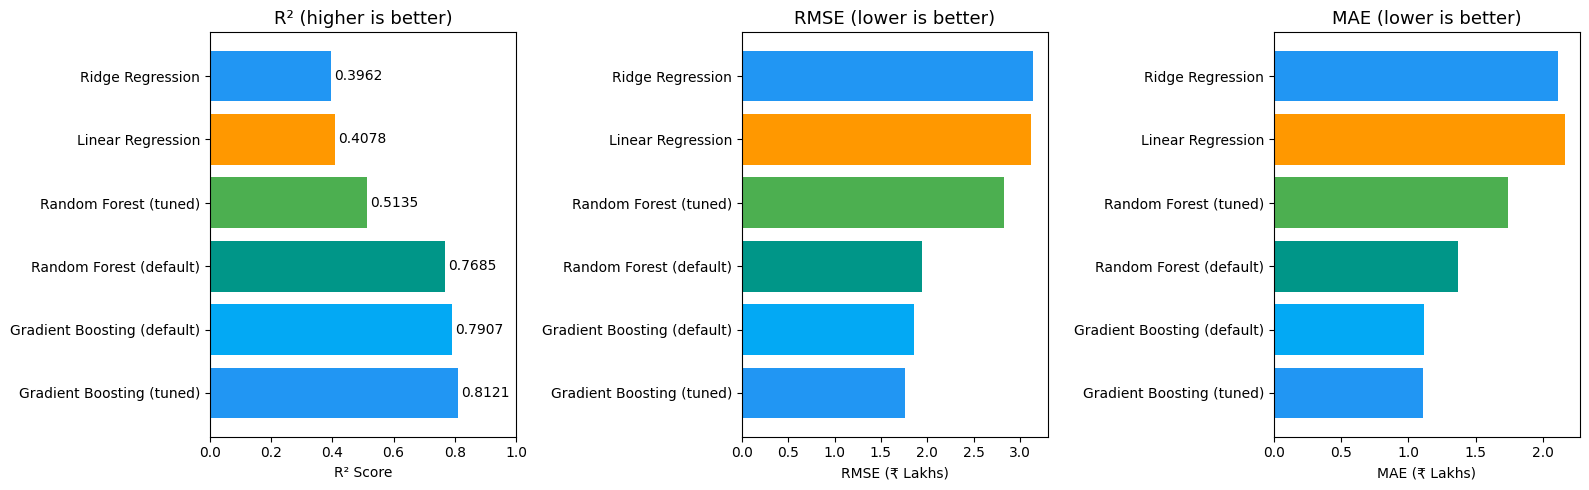

In [11]:
# Bar chart — R² comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['#2196F3', '#03A9F4', '#009688', '#4CAF50', '#FF9800']

axes[0].barh(df_results['Model'], df_results['R²'], color=colors[:len(df_results)])
axes[0].set_xlabel('R² Score')
axes[0].set_title('R² (higher is better)')
axes[0].set_xlim(0, 1)
for i, v in enumerate(df_results['R²']):
    axes[0].text(v + 0.01, i, str(v), va='center', fontsize=10)

axes[1].barh(df_results['Model'], df_results['RMSE (₹)'] / 1e5, color=colors[:len(df_results)])
axes[1].set_xlabel('RMSE (₹ Lakhs)')
axes[1].set_title('RMSE (lower is better)')

axes[2].barh(df_results['Model'], df_results['MAE (₹)'] / 1e5, color=colors[:len(df_results)])
axes[2].set_xlabel('MAE (₹ Lakhs)')
axes[2].set_title('MAE (lower is better)')

plt.tight_layout()
plt.savefig('plot_08_model_comparison.png', dpi=150)
plt.show()

---
## 6. Best Model — Detailed Evaluation

In [12]:
# Pick the best model based on R²
# We compare tuned RF vs tuned GB
rf_r2 = r2_score(y_test, preds_rf)
gb_r2 = r2_score(y_test, preds_gb)

if gb_r2 >= rf_r2:
    best_model  = gb_grid.best_estimator_
    best_preds  = preds_gb
    best_name   = 'Gradient Boosting (tuned)'
else:
    best_model  = rf_grid.best_estimator_
    best_preds  = preds_rf
    best_name   = 'Random Forest (tuned)'

print(f'Selected best model: {best_name}')
print(f'  R²   = {r2_score(y_test, best_preds):.4f}')
print(f'  RMSE = ₹{np.sqrt(mean_squared_error(y_test, best_preds)):,.0f}')
print(f'  MAE  = ₹{mean_absolute_error(y_test, best_preds):,.0f}')

Selected best model: Gradient Boosting (tuned)
  R²   = 0.8121
  RMSE = ₹175,486
  MAE  = ₹110,986


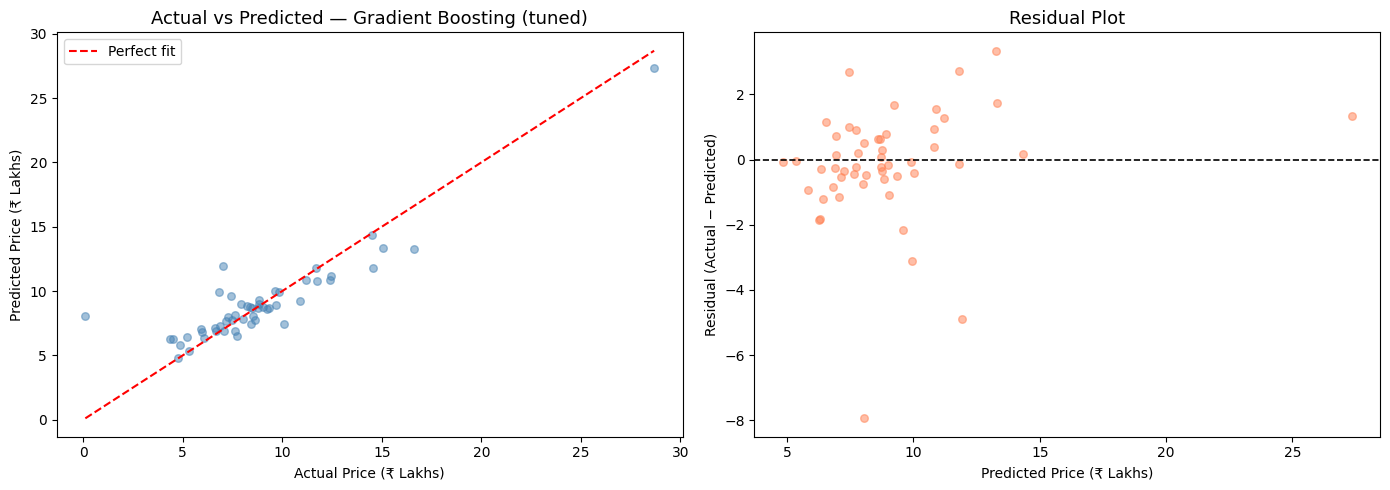

In [13]:
# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

actual_lakh = y_test.values / 1e5
pred_lakh   = best_preds / 1e5

axes[0].scatter(actual_lakh, pred_lakh, alpha=0.5, color='steelblue', s=30)
min_val = min(actual_lakh.min(), pred_lakh.min())
max_val = max(actual_lakh.max(), pred_lakh.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual Price (₹ Lakhs)')
axes[0].set_ylabel('Predicted Price (₹ Lakhs)')
axes[0].set_title(f'Actual vs Predicted — {best_name}')
axes[0].legend()

# Residuals
residuals = actual_lakh - pred_lakh
axes[1].scatter(pred_lakh, residuals, alpha=0.5, color='coral', s=30)
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Predicted Price (₹ Lakhs)')
axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.savefig('plot_09_actual_vs_predicted.png', dpi=150)
plt.show()

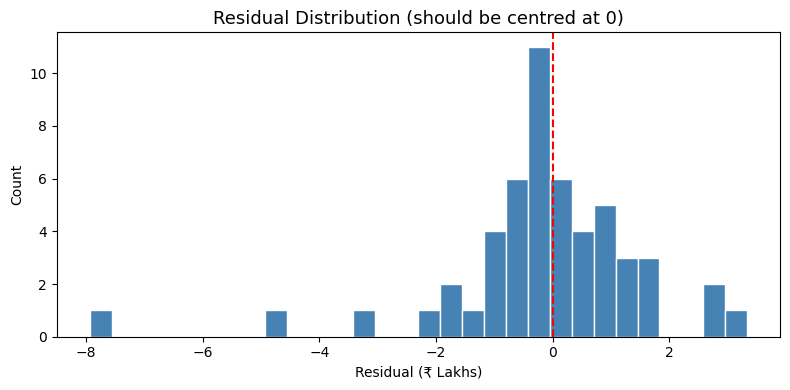

Mean residual : -0.1567 Lakhs
Std residual  : 1.7478 Lakhs


In [14]:
# Residual distribution
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=30, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residual (₹ Lakhs)')
plt.ylabel('Count')
plt.title('Residual Distribution (should be centred at 0)')
plt.tight_layout()
plt.savefig('plot_10_residual_distribution.png', dpi=150)
plt.show()

print(f'Mean residual : {residuals.mean():.4f} Lakhs')
print(f'Std residual  : {residuals.std():.4f} Lakhs')

---
## 7. Feature Importance

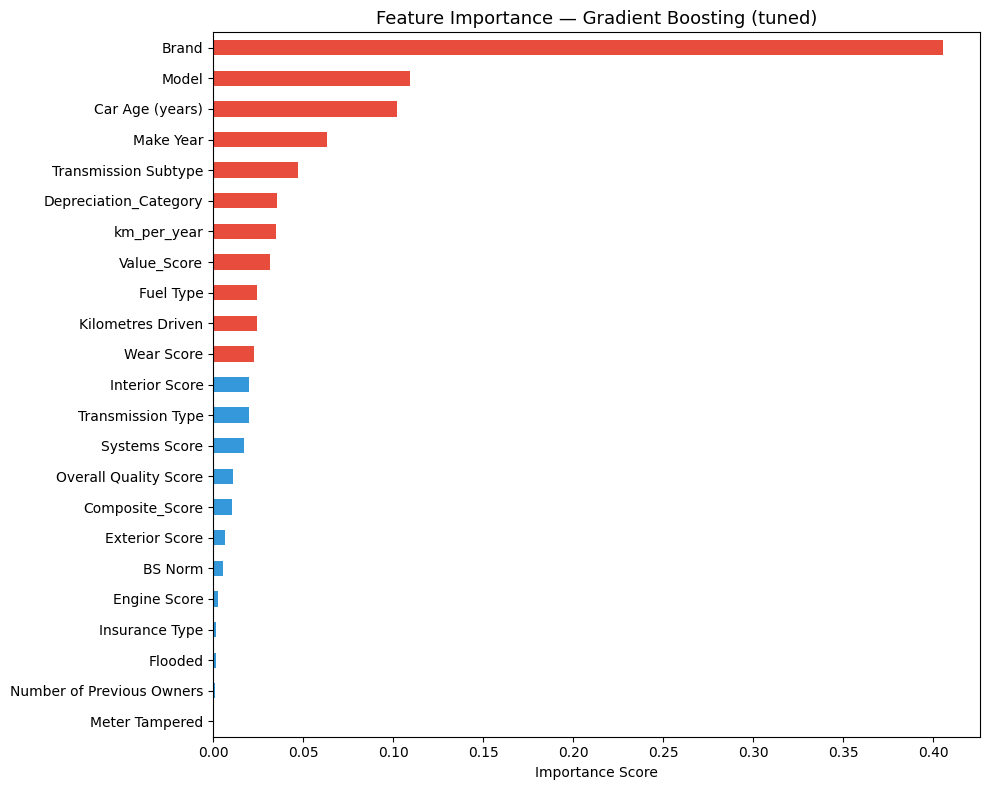


Top 10 most important features:
Brand                    0.405840
Model                    0.109194
Car Age (years)          0.102256
Make Year                0.063288
Transmission Subtype     0.047265
Depreciation_Category    0.035573
km_per_year              0.034702
Value_Score              0.031523
Fuel Type                0.024626
Kilometres Driven        0.024245


In [15]:
importances = pd.Series(
    best_model.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
colors_imp = ['#e74c3c' if v > importances.median() else '#3498db'
              for v in importances]
importances.plot.barh(color=colors_imp)
plt.xlabel('Importance Score')
plt.title(f'Feature Importance — {best_name}')
plt.tight_layout()
plt.savefig('plot_11_feature_importance.png', dpi=150)
plt.show()

print('\nTop 10 most important features:')
print(importances.sort_values(ascending=False).head(10).to_string())

---
## 8. Sample Predictions — 5 College SUV Profiles

In [16]:
# Load encoders from Stage 3
le_fuel      = joblib.load('le_fuel.pkl')
le_brand     = joblib.load('le_brand.pkl')
le_model_enc = joblib.load('le_model.pkl')
le_trans_sub = joblib.load('le_trans_sub.pkl')

def encode_input(brand, model_name, make_year, car_age, km_driven,
                 fuel, transmission, trans_sub, bs_norm, owners,
                 insurance, overall_q, engine_s, systems_s,
                 interior_s, exterior_s, wear_s, value_s,
                 depreciation, meter_tampered, flooded):

    # Encode categoricals — handle unseen labels gracefully
    def safe_encode(le, val):
        return le.transform([val])[0] if val in le.classes_ else 0

    owner_map = {'1st Owner': 1, '2nd Owner': 2, '3rd Owner': 3}
    dep_map   = {'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4}
    bs_map    = {'Unknown': 0, 'BSIV': 1, 'BSVI': 2}

    composite = np.mean([overall_q, engine_s, systems_s,
                         interior_s, exterior_s, wear_s])
    km_per_yr = km_driven // max(car_age, 1)

    row = {
        'Brand':                    safe_encode(le_brand, brand),
        'Model':                    safe_encode(le_model_enc, model_name),
        'Make Year':                make_year,
        'Car Age (years)':          car_age,
        'Kilometres Driven':        km_driven,
        'km_per_year':              km_per_yr,
        'Fuel Type':                safe_encode(le_fuel, fuel),
        'Transmission Type':        0 if transmission == 'Manual' else 1,
        'Transmission Subtype':     safe_encode(le_trans_sub, trans_sub),
        'BS Norm':                  bs_map.get(bs_norm, 0),
        'Number of Previous Owners': owner_map.get(owners, 1),
        'Insurance Type':           0 if insurance == 'Third Party' else 1,
        'Overall Quality Score':    overall_q,
        'Engine Score':             engine_s,
        'Systems Score':            systems_s,
        'Interior Score':           interior_s,
        'Exterior Score':           exterior_s,
        'Wear Score':               wear_s,
        'Composite_Score':          round(composite, 3),
        'Value_Score':              value_s,
        'Depreciation_Category':    dep_map.get(depreciation, 2),
        'Meter Tampered':           0 if meter_tampered == 'No' else 1,
        'Flooded':                  0 if flooded == 'No' else 1,
    }
    return pd.DataFrame([row])[FEATURES]

# 5 College SUV profiles
college_suvs = [
    dict(label='SUV #1 — Tata Nexon (2021, Petrol, Manual)',
         brand='Tata', model_name='Nexon', make_year=2021, car_age=4,
         km_driven=50000, fuel='Petrol', transmission='Manual',
         trans_sub='Regular', bs_norm='BSVI', owners='1st Owner',
         insurance='Comprehensive', overall_q=8.5, engine_s=9.0,
         systems_s=8.8, interior_s=8.2, exterior_s=8.5, wear_s=8.3,
         value_s=7.2, depreciation='High',
         meter_tampered='No', flooded='No'),

    dict(label='SUV #2 — Hyundai Creta (2020, Diesel, Manual)',
         brand='Hyundai', model_name='Creta', make_year=2020, car_age=5,
         km_driven=72000, fuel='Diesel', transmission='Manual',
         trans_sub='Regular', bs_norm='BSVI', owners='1st Owner',
         insurance='Comprehensive', overall_q=8.2, engine_s=8.8,
         systems_s=8.5, interior_s=7.9, exterior_s=8.0, wear_s=7.8,
         value_s=6.9, depreciation='High',
         meter_tampered='No', flooded='No'),

    dict(label='SUV #3 — Kia Seltos (2022, Petrol, Automatic)',
         brand='Kia', model_name='Seltos', make_year=2022, car_age=3,
         km_driven=35000, fuel='Petrol', transmission='Automatic',
         trans_sub='DCT', bs_norm='BSVI', owners='1st Owner',
         insurance='Comprehensive', overall_q=9.0, engine_s=9.2,
         systems_s=9.0, interior_s=8.8, exterior_s=8.9, wear_s=9.1,
         value_s=7.8, depreciation='Medium',
         meter_tampered='No', flooded='No'),

    dict(label='SUV #4 — Maruti Suzuki Brezza (2019, Petrol, Manual)',
         brand='Maruti Suzuki', model_name='Brezza', make_year=2019, car_age=6,
         km_driven=85000, fuel='Petrol', transmission='Manual',
         trans_sub='Regular', bs_norm='BSIV', owners='2nd Owner',
         insurance='Third Party', overall_q=7.5, engine_s=7.8,
         systems_s=7.6, interior_s=7.0, exterior_s=7.2, wear_s=7.0,
         value_s=6.2, depreciation='Very High',
         meter_tampered='No', flooded='No'),

    dict(label='SUV #5 — Mahindra XUV (2018, Diesel, Manual)',
         brand='Mahindra', model_name='XUV', make_year=2018, car_age=7,
         km_driven=110000, fuel='Diesel', transmission='Manual',
         trans_sub='Regular', bs_norm='BSIV', owners='2nd Owner',
         insurance='Third Party', overall_q=7.0, engine_s=7.5,
         systems_s=7.2, interior_s=6.8, exterior_s=6.9, wear_s=6.5,
         value_s=5.8, depreciation='Very High',
         meter_tampered='No', flooded='No'),
]

print('='*65)
print('         5 SAMPLE PREDICTIONS — COLLEGE SUVs')
print('='*65)

sample_results = []
for suv in college_suvs:
    label = suv.pop('label')
    X_input = encode_input(**suv)
    price   = best_model.predict(X_input)[0]
    lakh    = price / 1e5
    print(f'  {label}')
    print(f'  Estimated Price : ₹{price:>12,.0f}  ({lakh:.2f} Lakhs)')
    print()
    sample_results.append({'Car': label, 'Estimated Price (₹)': f'{price:,.0f}', 'In Lakhs': f'{lakh:.2f}'})

print('='*65)
pd.DataFrame(sample_results)

         5 SAMPLE PREDICTIONS — COLLEGE SUVs
  SUV #1 — Tata Nexon (2021, Petrol, Manual)
  Estimated Price : ₹     642,387  (6.42 Lakhs)

  SUV #2 — Hyundai Creta (2020, Diesel, Manual)
  Estimated Price : ₹     919,141  (9.19 Lakhs)

  SUV #3 — Kia Seltos (2022, Petrol, Automatic)
  Estimated Price : ₹   1,077,670  (10.78 Lakhs)

  SUV #4 — Maruti Suzuki Brezza (2019, Petrol, Manual)
  Estimated Price : ₹     466,798  (4.67 Lakhs)

  SUV #5 — Mahindra XUV (2018, Diesel, Manual)
  Estimated Price : ₹     554,377  (5.54 Lakhs)



,Car,Estimated Price (₹),In Lakhs
0,"SUV #1 — Tata Nexon (2021, Petrol, Manual)","642,387",6.42
1,"SUV #2 — Hyundai Creta (2020, Diesel, Manual)","919,141",9.19
2,"SUV #3 — Kia Seltos (2022, Petrol, Automatic)","1,077,670",10.78
3,"SUV #4 — Maruti Suzuki Brezza (2019, Petrol, M...","466,798",4.67
4,"SUV #5 — Mahindra XUV (2018, Diesel, Manual)","554,377",5.54


---
## 9. Save Best Model

In [17]:
joblib.dump(best_model, 'model.pkl')
print(f'Saved best model → model.pkl')
print(f'Model type : {type(best_model).__name__}')

print('\n' + '='*55)
print('           STAGE 4 SUMMARY')
print('='*55)
print(df_results.to_string(index=False))
print('='*55)
print(f'Best model saved  : model.pkl')
print(f'Ready for Stage 5 : app.py (Flask deployment)')
print('='*55)

Saved best model → model.pkl
Model type : GradientBoostingRegressor

           STAGE 4 SUMMARY
                      Model  RMSE (₹)  MAE (₹)     R²  CV R²
  Gradient Boosting (tuned)    175486   110986 0.8121 0.4831
Gradient Boosting (default)    185179   111867 0.7907 0.4419
    Random Forest (default)    194747   137073 0.7685 0.4764
      Random Forest (tuned)    282331   174177 0.5135 0.3629
          Linear Regression    311488   216756 0.4078 0.1792
           Ridge Regression    314542   211007 0.3962 0.2450
Best model saved  : model.pkl
Ready for Stage 5 : app.py (Flask deployment)
